# 🔬 SPMS Capstone: Data Preprocessing & LSTM Exploration

**Purpose:** This is a structured exploration notebook. It standardizes the pipeline from raw ingestion to 3D tensor generation for LSTM training. 

---

### ⚠️ TEAM INSTRUCTIONS & HUMAN CONFIGURATION REQUIRED
All hyperparameters, thresholds, and file paths are isolated in the **Global Configuration** block below. 
Before running this notebook, the team must agree on:
1. `WINDOW_SIZE`: How many past time steps the LSTM should look at.
2. `TRAIN_SPLIT`: The proportion of data used for training vs validation.
3. `TARGET_FEATURES`: The exact sensor columns to include in the model.

In [17]:
# 1. IMPORTS (Production Standard)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout

# Set plotting style for professional readable charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

## ⚙️ Global Configuration Block
**TEAM ACTION:** Adjust these parameters based on the current experimental phase.

In [18]:
# ==========================================
# 🛠️ HUMAN CONFIGURABLE PARAMETERS
# ==========================================

# I/O Paths
RAW_DATA_PATH = './data/master_data_labeled.csv' # UPDATE THIS TO YOUR ACTUAL CSV
MODEL_SAVE_DIR = '../models/'

# Time Series Parameters
WINDOW_SIZE = 15       # e.g., 30 minutes/steps lookback
FORECAST_HORIZON = 30   # Number of steps to predict into the future (if forecasting)

# Feature Selection
# Explicitly define columns to avoid garbage data entering the model.
FEATURES_TO_SCALE = [
    'impeller_rpm',
    'filter_clear_interval',
    'processtime_min',
    'chopper_rpm', 
    'impeller_ampere',
    'X-Axis RMS Velocity (mm/s)',
    'X-Axis Peak Acceleration (G)',
    'Temperature C',
    'impeller_rpm_variance',
    'Temperature C_variance',
    'impeller_ampere_variance'
]

# Training Parameters
TRAIN_SPLIT_RATIO = 0.8  # 80% Train, 20% Test/Validation
BATCH_SIZE = 64
EPOCHS = 15
# ==========================================


## 1. Data Ingestion & Sanity Checks
Loading data and ensuring the index is strictly temporal.

In [19]:
def load_and_verify_data(filepath):
    """Loads data, filters offline states, and performs sanity checks."""
    print(f"[*] Loading data from {filepath}...")
    # Load real data
    df = pd.read_csv(filepath, index_col='Timeline (Minute)', parse_dates=True)
    
    # --- DOMAIN SPECIFIC PREPROCESSING (Restoring V2 Logic) ---
    # 1. Drop redundant metric vs imperial columns and non-useful strings
    cols_to_drop = [
        'batch_id_clean', 'process_id_clean', 'readable_time',
        'X-Axis RMS Velocity (in/s)', 'Z-Axis RMS Velocity (in/s)',
        'pump_speed', 'Z-Axis RMS Velocity (mm/s)', 'Z-Axis Peak Acceleration (G)',
        'machine_state_cluster'
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    
    # 2. FILTER ABSOLUTE OFFLINE (CRITICAL)
    # We cannot train a "healthy" baseline on a machine that is turned off.
    if 'state_label' in df.columns:
        print(f"[*] Filtering out 'Absolute Offline'. Original rows: {len(df)}")
        df = df[df['state_label'] != 'Absolute Offline']
        print(f"[*] Rows after filtering: {len(df)}")
    
    # 3. Force numeric only to avoid model crashing
    df = df.select_dtypes(include=[np.number])
    
    print(f"[*] Final Data shape: {df.shape}")
    
    # Forward fill missing values to maintain temporal continuity, then drop remainder
    df = df.ffill().dropna()
    return df

df = load_and_verify_data(RAW_DATA_PATH)
display(df.head())

[*] Loading data from ./data/master_data_labeled.csv...
[*] Filtering out 'Absolute Offline'. Original rows: 414720
[*] Rows after filtering: 157503
[*] Final Data shape: (157503, 11)


,impeller_rpm,filter_clear_interval,processtime_min,chopper_rpm,impeller_ampere,X-Axis RMS Velocity (mm/s),X-Axis Peak Acceleration (G),Temperature C,impeller_rpm_variance,Temperature C_variance,impeller_ampere_variance
Timeline (Minute),,,,,,,,,,,
2025-05-30 15:20:00,0.0,100.0,5.0,0.0,0.0,0.146,0.032,30.41,0.0,7.851828,0.0
2025-05-30 15:21:00,0.0,100.0,5.0,0.0,0.0,0.184,0.035,30.49,0.0,10.714324,0.0
2025-05-30 15:22:00,0.0,100.0,5.0,0.0,0.0,0.135,0.033,30.47,0.0,12.610268,0.0
2025-05-30 15:23:00,0.0,100.0,5.0,0.0,0.0,0.122,0.029,30.47,0.0,13.942700,0.0
2025-05-30 15:24:00,0.0,100.0,5.0,0.0,0.0,0.121,0.028,30.49,0.0,14.865896,0.0


## 2. Exploratory Data Analysis (EDA) & Visualizations
Visualizing time-series integrity and feature correlations.

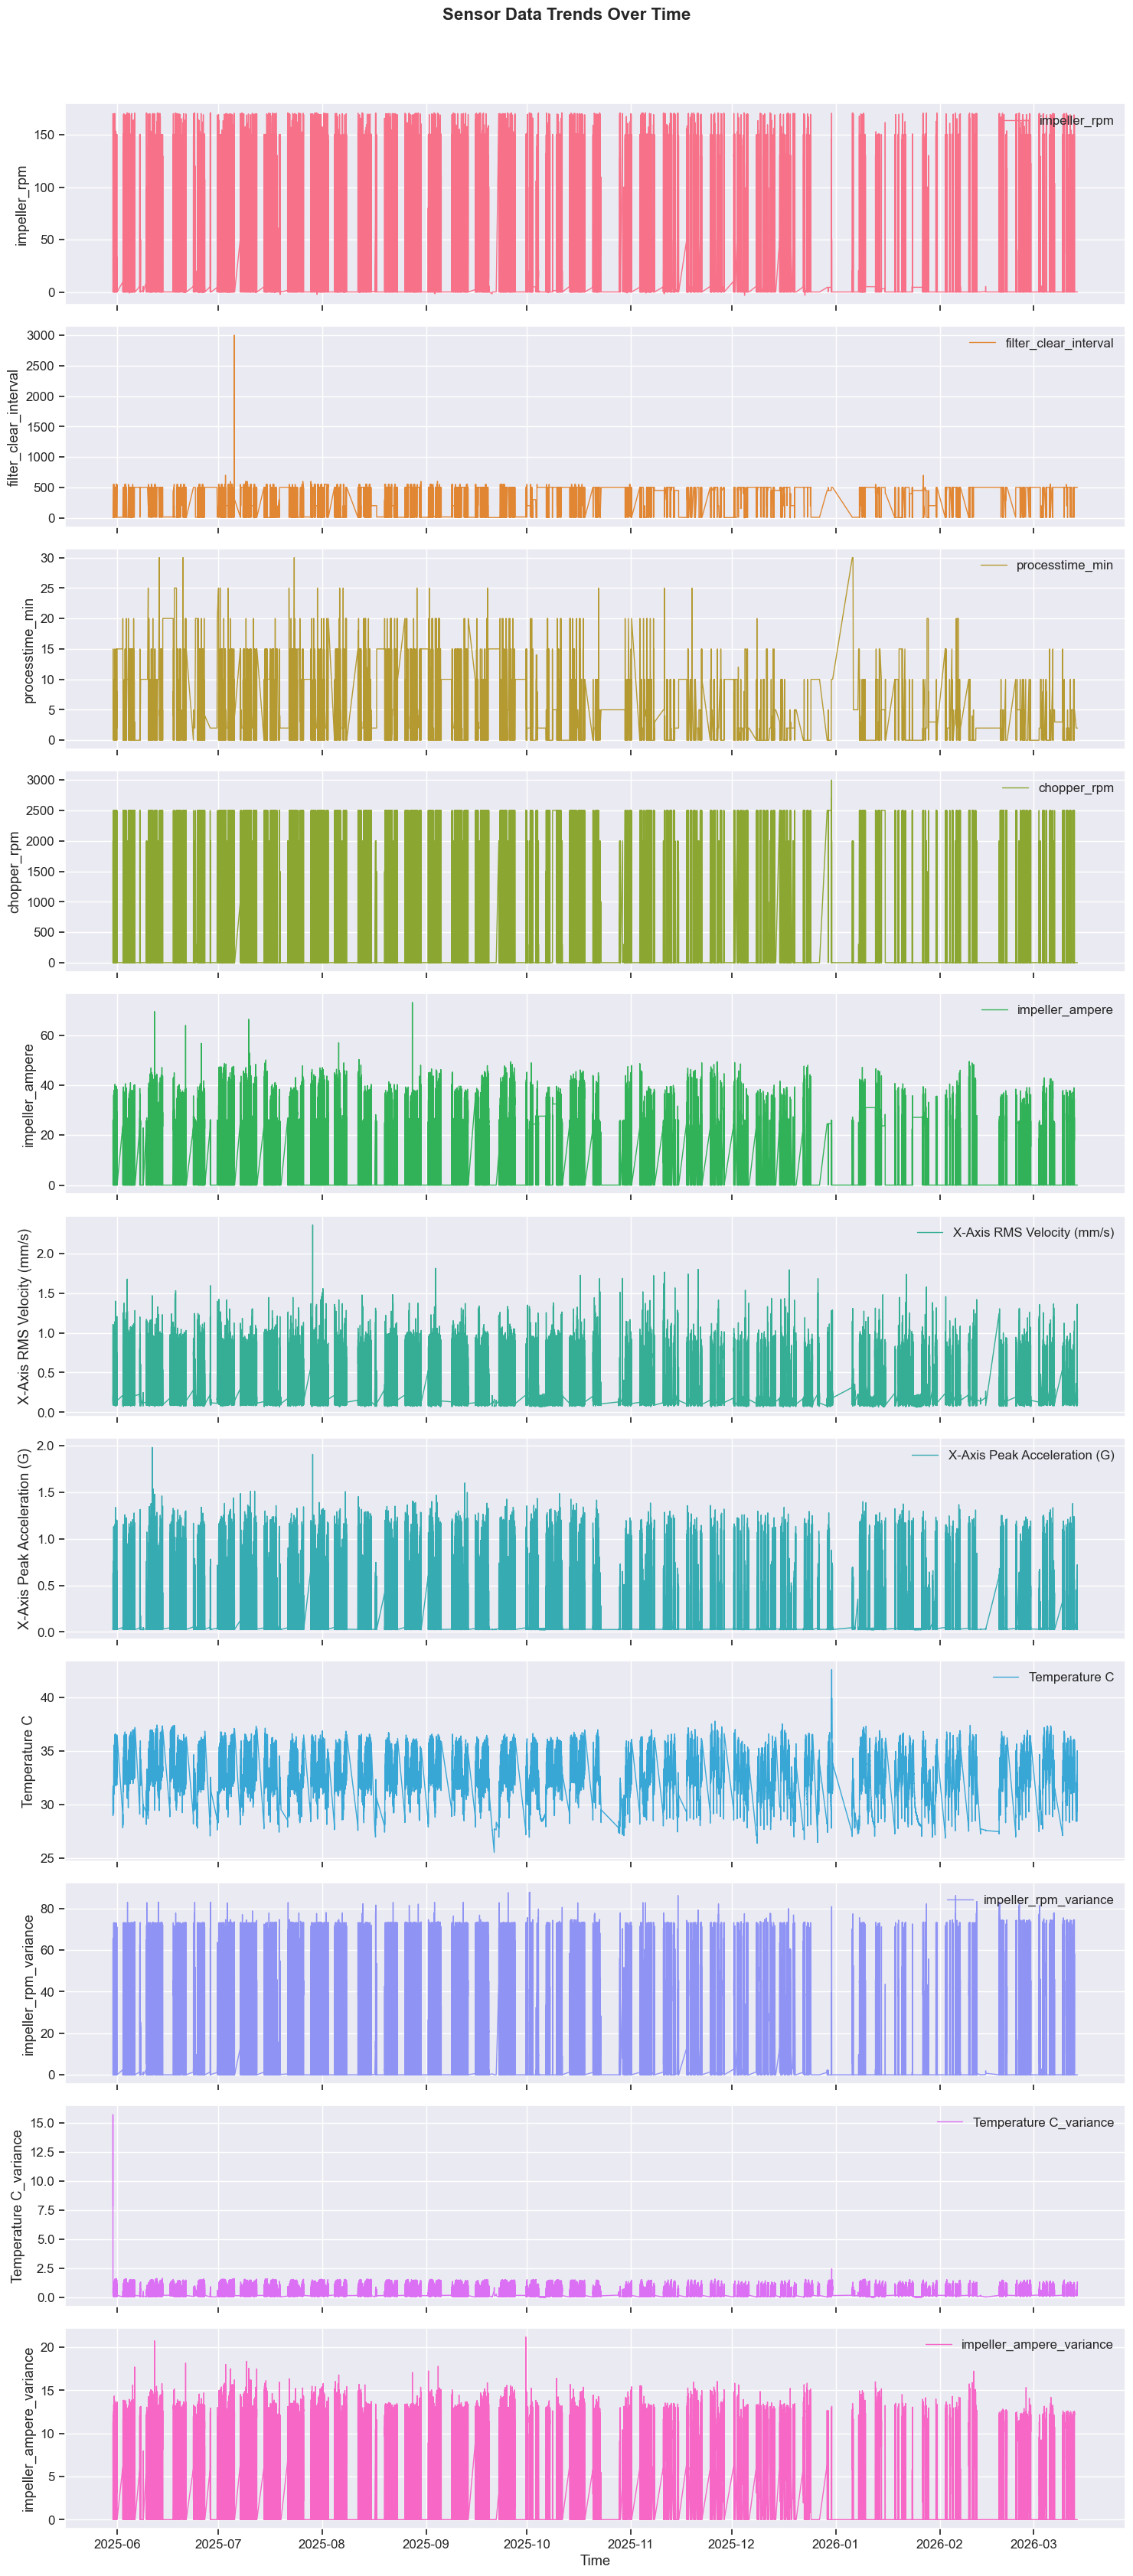

In [20]:
def plot_sensor_trends(data, features):
    """Generates a clean, multi-subplot time series view."""
    fig, axes = plt.subplots(nrows=len(features), ncols=1, figsize=(15, 3 * len(features)), sharex=True)
    if len(features) == 1:
        axes = [axes]
        
    for i, col in enumerate(features):
        axes[i].plot(data.index, data[col], label=col, color=sns.color_palette("husl", len(features))[i], linewidth=1)
        axes[i].set_ylabel(col)
        axes[i].legend(loc="upper right")
        
    plt.xlabel("Time")
    plt.suptitle("Sensor Data Trends Over Time", y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_sensor_trends(df, FEATURES_TO_SCALE)

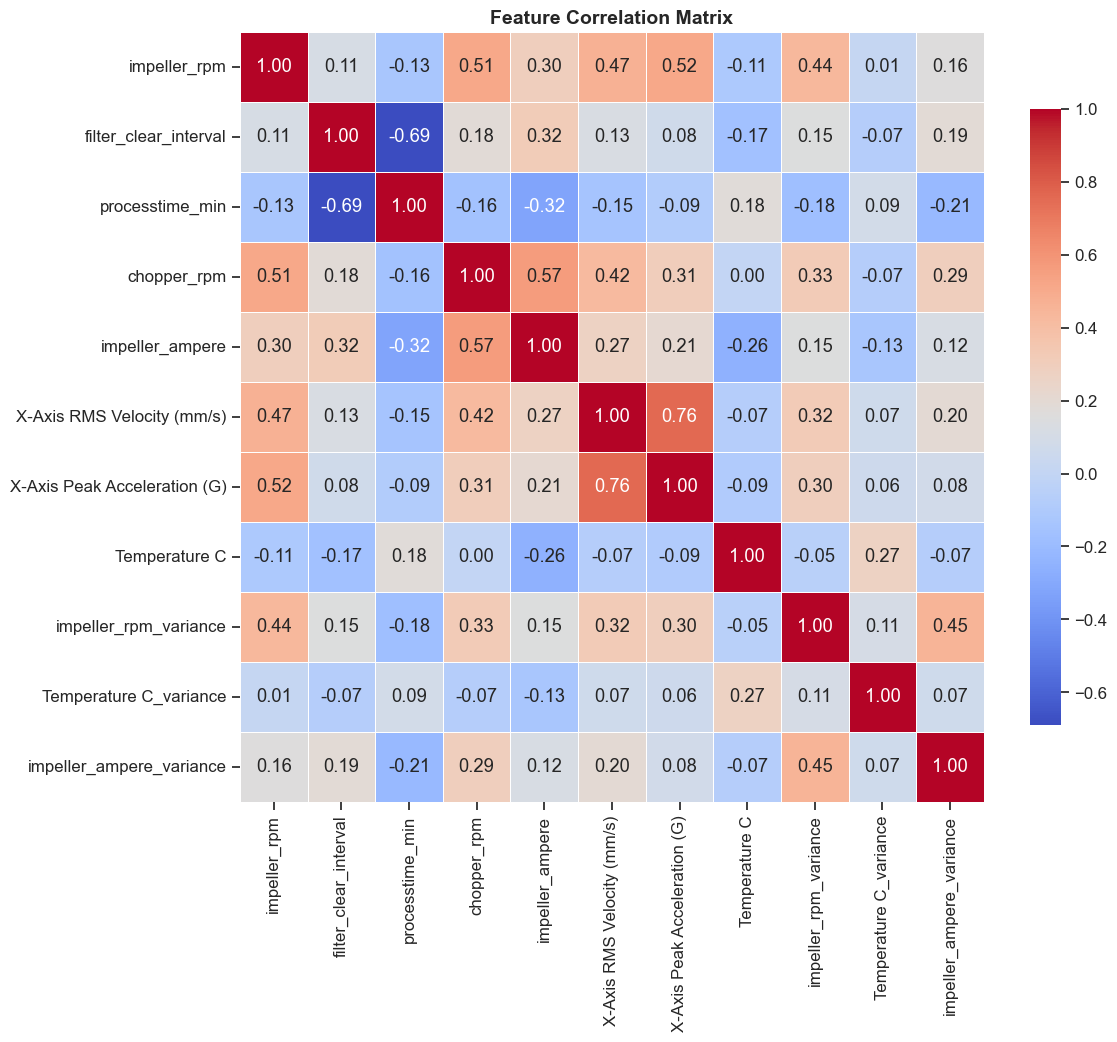

In [21]:
def plot_correlation_matrix(data):
    """Identifies multicollinearity among features."""
    plt.figure(figsize=(12, 10))
    corr = data[FEATURES_TO_SCALE].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
    plt.show()

plot_correlation_matrix(df)

## 3. Train/Test Split & Scaling (Avoiding Data Leakage)
**LORE'S WARNING:** Never scale the entire dataset before splitting. Fit the `MinMaxScaler` ONLY on the training data, then transform both train and test. Scaling everything together introduces future data leakage.

In [22]:
# 1. Sequential Split (Do NOT shuffle time-series data)
train_size = int(len(df) * TRAIN_SPLIT_RATIO)
train_data = df.iloc[:train_size][FEATURES_TO_SCALE].copy()
test_data = df.iloc[train_size:][FEATURES_TO_SCALE].copy()

print(f"[*] Training samples: {len(train_data)}")
print(f"[*] Testing samples: {len(test_data)}")

# 2. Scaling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# (Optional) Save the scaler for inference in production
# joblib.dump(scaler, os.path.join(MODEL_SAVE_DIR, 'scaler.pkl'))

[*] Training samples: 125856
[*] Testing samples: 31465


## 4. 3D Tensor Generation for LSTM
LSTMs require input data in 3D format: `[samples, time_steps, features]`. We generate overlapping sliding windows.

In [23]:
def create_sequences(data, window_size):
    """
    Transforms 2D tabular data into 3D tensors.
    X shape: (samples, window_size, features)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        # For an Autoencoder, the target is the same as the input.
        # For forecasting, y would be data[i + window_size]
        y.append(data[i : i + window_size]) 
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

print(f"[*] X_train shape (Samples, Timesteps, Features): {X_train.shape}")
print(f"[*] X_test shape (Samples, Timesteps, Features): {X_test.shape}")

[*] X_train shape (Samples, Timesteps, Features): (125841, 15, 11)
[*] X_test shape (Samples, Timesteps, Features): (31450, 15, 11)


## 5. LSTM Autoencoder Definition (Baseline Architecture)
This is a starter architecture for anomaly detection using reconstruction error.

In [24]:
def build_lstm_autoencoder(timesteps, num_features):
    model = Sequential([
        # Encoder
        LSTM(64, activation='relu', input_shape=(timesteps, num_features), return_sequences=True),
        LSTM(32, activation='relu', return_sequences=False),
        Dropout(0.2),
        
        # Bottleneck (Latent Representation)
        RepeatVector(timesteps),
        
        # Decoder
        LSTM(32, activation='relu', return_sequences=True),
        LSTM(64, activation='relu', return_sequences=True),
        
        # Output Layer
        TimeDistributed(Dense(num_features))
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_autoencoder(X_train.shape[1], X_train.shape[2])
model.summary()

c:\Users\filbe\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 15, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 15, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 15, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 15, 11)         │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,739 (256.79 KB)

 Trainable params: 65,739 (256.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training & Validation
Training the Autoencoder. We use EarlyStopping to prevent overfitting.

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("[*] Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# Save the model (Uncomment for production)
# model.save(os.path.join(MODEL_SAVE_DIR, 'lstm_autoencoder.h5'))

[*] Starting training...
Epoch 1/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 0.0133 - val_loss: 0.0064
Epoch 2/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0078 - val_loss: 0.0058
Epoch 3/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0063 - val_loss: 0.0050
Epoch 4/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.0054 - val_loss: 0.0050
Epoch 5/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 6/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 7/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 8/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 9/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 10/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0038 - val_loss: 0.0045
Epoch 11/15
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0037 - 

## 7. Reconstruction Error & Thresholding
Visualizing the loss curve and calculating the Mean Absolute Error (MAE) to determine the anomaly threshold.

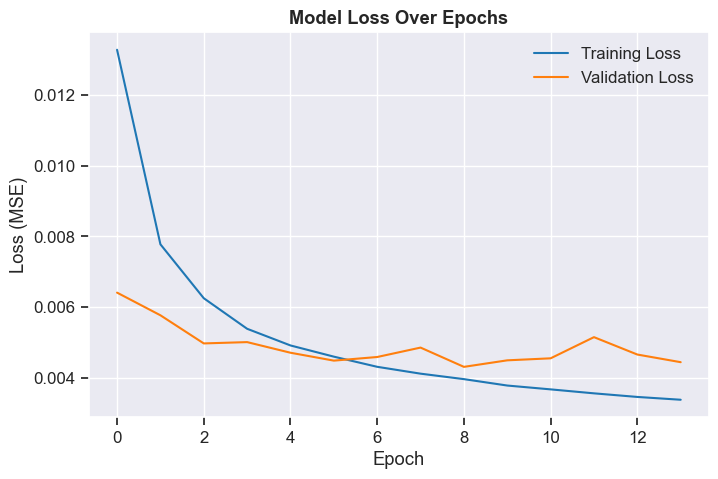

3933/3933 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step


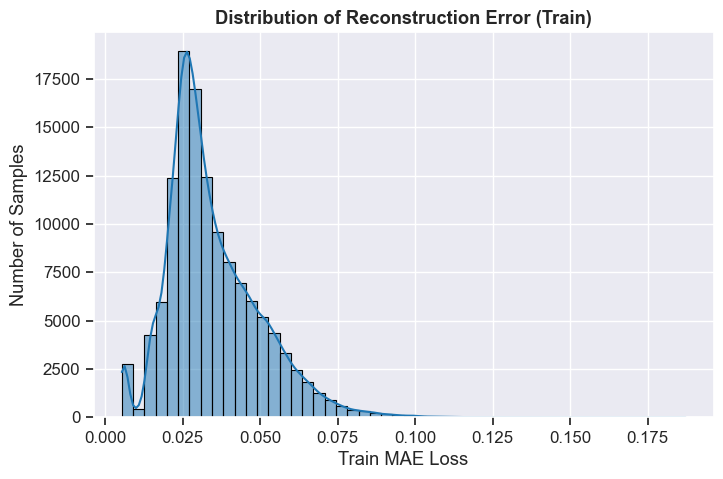

[*] Calculated Anomaly Threshold: 0.1778


In [26]:
# Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs', fontweight='bold')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Calculate Reconstruction Error on Training Data
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

plt.figure(figsize=(8, 5))
sns.histplot(train_mae_loss, bins=50, kde=True)
plt.title('Distribution of Reconstruction Error (Train)', fontweight='bold')
plt.xlabel('Train MAE Loss')
plt.ylabel('Number of Samples')
plt.show()

# Define Anomaly Threshold (e.g., max train loss or 99th percentile)
threshold = np.max(train_mae_loss) * 0.95  # Adjust this factor based on domain knowledge
print(f"[*] Calculated Anomaly Threshold: {threshold:.4f}")

## 8. Anomaly Evaluation on Test Set
Applying the threshold to the test set to flag anomalies.

983/983 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
[*] Number of anomalies detected in Test Set: 0 out of 31450 samples


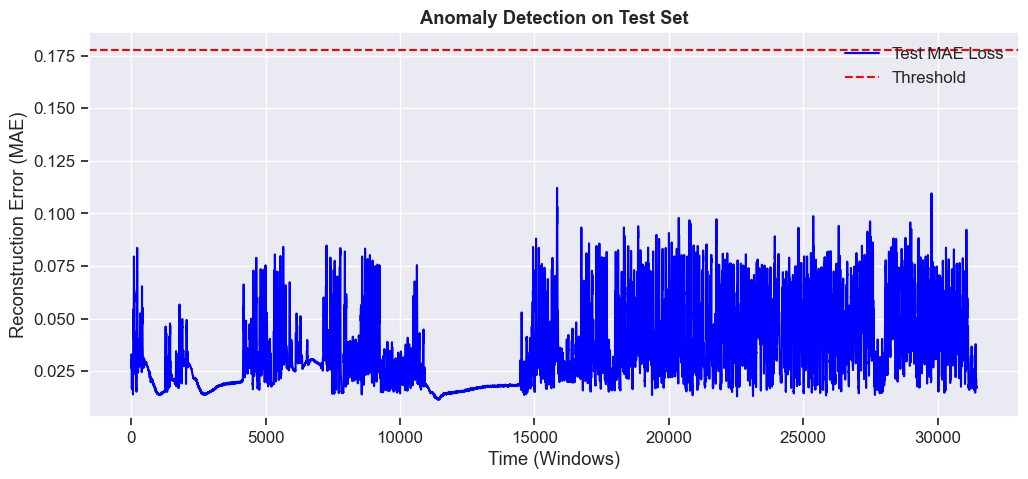

In [27]:
# Predict on Test Set
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))

# Flag Anomalies
anomalies = test_mae_loss > threshold
print(f"[*] Number of anomalies detected in Test Set: {np.sum(anomalies)} out of {len(test_mae_loss)} samples")

# Visualize Anomalies over Time
plt.figure(figsize=(12, 5))
plt.plot(test_mae_loss, label='Test MAE Loss', color='blue')
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
plt.title('Anomaly Detection on Test Set', fontweight='bold')
plt.ylabel('Reconstruction Error (MAE)')
plt.xlabel('Time (Windows)')
plt.legend()
plt.show()

## 9. Mapping Anomalies Back to Original Data (Contextualization)
This step aligns the detected anomalies from the 3D windows back to their original timestamps so the team can see exactly *when* the machine failed.

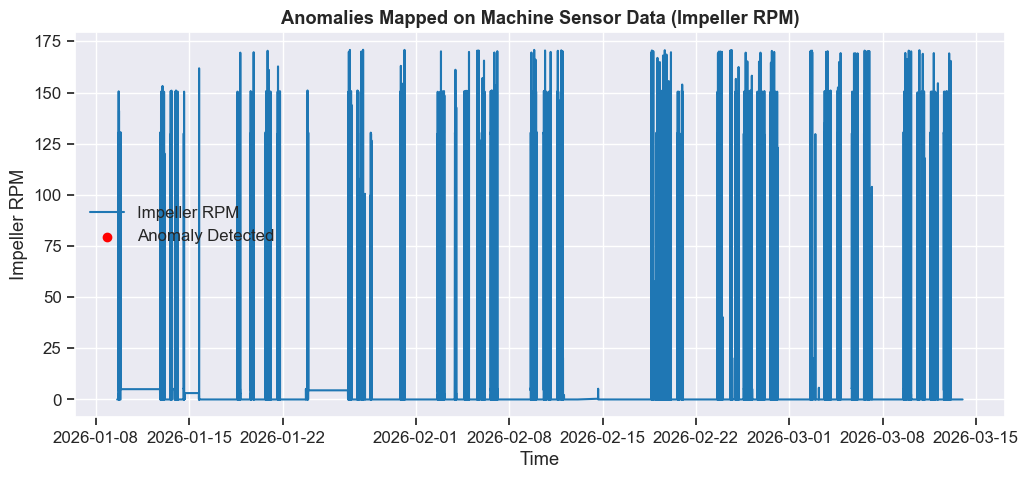

In [28]:
# Create a DataFrame for test results
# Note: The test sequences start at index 'train_size + WINDOW_SIZE'
test_score_df = pd.DataFrame(index=df.iloc[train_size + WINDOW_SIZE:].index)
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = threshold
test_score_df['anomaly'] = anomalies
test_score_df['impeller_rpm'] = test_data['impeller_rpm'].iloc[WINDOW_SIZE:].values

# Visualize the actual metric (e.g., impeller_rpm) highlighting the anomalies
anomalies_data = test_score_df[test_score_df['anomaly'] == True]

plt.figure(figsize=(12, 5))
plt.plot(test_score_df.index, test_score_df['impeller_rpm'], label='Impeller RPM')
plt.scatter(anomalies_data.index, anomalies_data['impeller_rpm'], color='red', label='Anomaly Detected')
plt.title('Anomalies Mapped on Machine Sensor Data (Impeller RPM)', fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Impeller RPM')
plt.legend()
plt.show()

## 10. Next Steps / Production
**For the Team:**
1. Discuss the threshold approach (is 95% of max train MAE too strict/lenient?).
2. If this performs well on the real Capstone data, this notebook is ready to be modularized into `.py` scripts (e.g., `data_loader.py`, `model_builder.py`, `train.py`) for the final FastAPI deployment.
3. Save the trained scaler and model weights once parameters are finalized.